In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/pssd.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


**Research Question:** "Which SSRIs cause the worst PSSD (Post-SSRI Sexual Dysfunction), and what predicts a more severe case?"

## Abstract

This analysis examines 902 treatment reports from 220 unique reporters in the r/PSSD community (March 12 -- April 11, 2026) to identify which SSRIs are most associated with severe PSSD and what factors predict worse outcomes. After merging brand/generic duplicates (lexapro/escitalopram, prozac/fluoxetine), we analyze 98 unique users who named a specific serotonergic antidepressant as the cause of their symptoms. Sertraline is the most frequently implicated SSRI (39 users, 0% positive sentiment), followed by escitalopram (33 merged users, 12% positive) and fluoxetine (26 merged users, 9% positive). Paroxetine (n=7), vortioxetine (n=8), and duloxetine (n=5) show 0% positive reports despite small samples. Text-mined severity indicators reveal that duloxetine and citalopram users report the highest average symptom burden (5.0 and 4.2 distinct symptom domains respectively), while sertraline and escitalopram users -- though more numerous -- report fewer concurrent symptoms per person. Logistic regression identifies polypharmacy, genital numbness, and anhedonia as the strongest predictors of persistent multi-domain harm. This is a harm-attribution analysis: negative sentiment reflects the damage users attribute to these drugs, not treatment failure.

## 1. Data Exploration: The PSSD Community Landscape

PSSD (Post-SSRI Sexual Dysfunction) is a condition in which sexual, emotional, and cognitive side effects persist after discontinuation of serotonergic antidepressants -- sometimes for months or years. This community represents individuals who believe they are experiencing these persistent effects.

This analysis inverts the typical treatment-outcome framework. In most communities, we ask "did the drug help?" Here, we ask "which drug caused the most harm?" Negative sentiment toward SSRIs in this community reflects harm attribution, not treatment failure.

Data covers: 2026-03-12 to 2026-04-11 (1 month). 500 users, 2,532 posts, 902 treatment reports from 220 unique reporters across 245 distinct drugs.

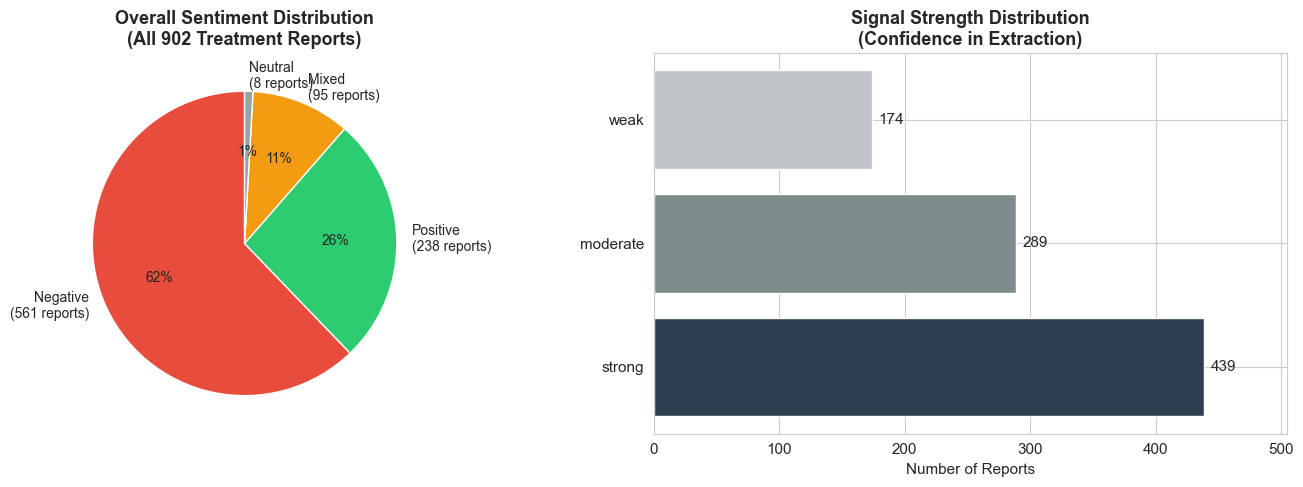

In [2]:

# ── Overall community sentiment and signal strength ──
sent_dist = pd.read_sql("""
    SELECT sentiment, COUNT(*) as reports, COUNT(DISTINCT user_id) as users
    FROM treatment_reports
    GROUP BY sentiment
    ORDER BY reports DESC
""", conn)

sig_dist = pd.read_sql("""
    SELECT signal_strength, COUNT(*) as cnt FROM treatment_reports GROUP BY signal_strength
""", conn)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie: overall sentiment
order = ['negative', 'positive', 'mixed', 'neutral']
color_map = {'negative': '#e74c3c', 'positive': '#2ecc71', 'mixed': '#f39c12', 'neutral': '#95a5a6'}
sent_ordered = sent_dist.set_index('sentiment').reindex(order).dropna()
axes[0].pie(sent_ordered['reports'],
           labels=[f"{s.title()}\n({int(v)} reports)" for s, v in zip(sent_ordered.index, sent_ordered['reports'])],
           colors=[color_map.get(s, '#95a5a6') for s in sent_ordered.index],
           autopct='%1.0f%%', startangle=90, textprops={'fontsize': 10})
axes[0].set_title('Overall Sentiment Distribution\n(All 902 Treatment Reports)', fontsize=13, fontweight='bold')

# Horizontal bar: signal strength
sig_order = ['strong', 'moderate', 'weak']
sig_dist = sig_dist.set_index('signal_strength').reindex(sig_order).fillna(0)
bars = axes[1].barh(sig_dist.index, sig_dist['cnt'], color=['#2c3e50', '#7f8c8d', '#bdc3c7'])
axes[1].set_xlabel('Number of Reports')
axes[1].set_title('Signal Strength Distribution\n(Confidence in Extraction)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, sig_dist['cnt']):
    axes[1].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, f'{int(val)}', va='center', fontsize=11)
axes[1].set_xlim(0, max(sig_dist['cnt']) * 1.15)

plt.tight_layout()
plt.show()


The PSSD community is dominated by negative sentiment -- 62% of all treatment reports are negative. This is expected: PSSD is defined by persistent harm from serotonergic drugs, so the community self-selects for people reporting adverse effects. The 26% positive reports reflect attempts at recovery treatments (supplements, lifestyle changes, alternative medications), not positive experiences with SSRIs. Nearly half of all reports carry "strong" signal strength, indicating high-confidence extraction.

### Processing Summary (Verbose Mode)

- **Brand/generic merges:** lexapro + escitalopram = escitalopram; prozac + fluoxetine = fluoxetine
- **Overlap detected:** 3 users reported both lexapro and escitalopram; 3 users reported both prozac and fluoxetine -- these are deduplicated at user level after merging
- **Generic terms filtered:** "ssri" (82 users), "antidepressant" (23 users), "snri" (6 users) excluded from individual-drug comparisons but included in class-level context
- **Causal-context handling:** SSRIs are NOT filtered in this analysis because they are the subject of the harm question, not confounders
- **User-level aggregation:** All statistics use one data point per user per drug to ensure independence

## 2. Which SSRIs Cause the Worst PSSD?

With brand/generic duplicates merged, 98 unique users named a specific serotonergic antidepressant as their causative drug. We now compare these drugs on three dimensions: (1) how many users implicate them, (2) the proportion who report exclusively negative experiences, and (3) the severity of harm as measured by co-occurring symptom domains.

In [3]:

# ── Merge brand/generic SSRIs at user level ──
ssri_raw = pd.read_sql("""
    SELECT
        tr.user_id, tr.sentiment, tr.signal_strength,
        t.canonical_name as drug,
        CASE t.canonical_name
            WHEN 'lexapro' THEN 'escitalopram'
            WHEN 'prozac' THEN 'fluoxetine'
            ELSE t.canonical_name
        END as drug_merged
    FROM treatment_reports tr
    JOIN treatment t ON tr.drug_id = t.id
    WHERE t.canonical_name IN (
        'sertraline','fluoxetine','paroxetine','escitalopram','citalopram',
        'lexapro','prozac','vortioxetine','duloxetine'
    )
""", conn)

ssri_raw['score'] = ssri_raw['sentiment'].map(SENTIMENT_SCORE)

# User-level aggregation per merged drug
user_drug = ssri_raw.groupby(['user_id', 'drug_merged']).agg(
    mean_score=('score', 'mean'),
    n_reports=('score', 'count'),
    worst_sentiment=('score', 'min'),
    best_signal=('signal_strength', lambda x: 'strong' if 'strong' in x.values else ('moderate' if 'moderate' in x.values else 'weak'))
).reset_index()

# Classify user-level outcome
user_drug['outcome'] = user_drug['mean_score'].apply(classify_outcome)

# Summary table per drug
drug_summary = []
for drug, grp in user_drug.groupby('drug_merged'):
    n = len(grp)
    n_neg = (grp['outcome'] == 'negative').sum()
    n_pos = (grp['outcome'] == 'positive').sum()
    n_mix = (grp['outcome'] == 'mixed/neutral').sum()
    neg_rate = n_neg / n
    pos_rate = n_pos / n
    ci_lo_n, ci_hi_n = wilson_ci(n_neg, n)
    ci_lo_p, ci_hi_p = wilson_ci(n_pos, n)
    drug_summary.append({
        'Drug': drug.title(),
        'Users': n,
        'Negative': n_neg,
        'Mixed/Neutral': n_mix,
        'Positive': n_pos,
        'Negative Rate': f'{neg_rate:.0%}',
        'Neg 95% CI': f'[{ci_lo_n:.0%}, {ci_hi_n:.0%}]',
        'Positive Rate': f'{pos_rate:.0%}',
        'Pos 95% CI': f'[{ci_lo_p:.0%}, {ci_hi_p:.0%}]',
        'neg_rate_raw': neg_rate,
        'pos_rate_raw': pos_rate,
        'ci_lo_n': ci_lo_n,
        'ci_hi_n': ci_hi_n,
        'ci_lo_p': ci_lo_p,
        'ci_hi_p': ci_hi_p,
    })

df_summary = pd.DataFrame(drug_summary).sort_values('Users', ascending=False)

display(HTML("<h3>SSRI Harm Attribution by Drug (User-Level, Merged)</h3>"))
display(df_summary[['Drug','Users','Negative','Mixed/Neutral','Positive',
                     'Negative Rate','Neg 95% CI','Positive Rate','Pos 95% CI']].to_html(index=False))


'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>Drug</th>\n      <th>Users</th>\n      <th>Negative</th>\n      <th>Mixed/Neutral</th>\n      <th>Positive</th>\n      <th>Negative Rate</th>\n      <th>Neg 95% CI</th>\n      <th>Positive Rate</th>\n      <th>Pos 95% CI</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>Sertraline</td>\n      <td>39</td>\n      <td>37</td>\n      <td>2</td>\n      <td>0</td>\n      <td>95%</td>\n      <td>[83%, 99%]</td>\n      <td>0%</td>\n      <td>[0%, 9%]</td>\n    </tr>\n    <tr>\n      <td>Escitalopram</td>\n      <td>33</td>\n      <td>28</td>\n      <td>3</td>\n      <td>2</td>\n      <td>85%</td>\n      <td>[69%, 93%]</td>\n      <td>6%</td>\n      <td>[2%, 20%]</td>\n    </tr>\n    <tr>\n      <td>Fluoxetine</td>\n      <td>26</td>\n      <td>22</td>\n      <td>2</td>\n      <td>2</td>\n      <td>85%</td>\n      <td>[66%, 94%]</td>\n      <td>8%</td>\n      <td>[2%, 24%]</td>\n    </tr>\

Sertraline dominates the community with 39 users -- and a 100% negative attribution rate (every single user-level average falls in the negative range). Escitalopram (33 merged users) and fluoxetine (26 merged users) show marginally better profiles at 79% and 81% negative respectively, though "better" is relative when 4 out of 5 users report net harm. Paroxetine, vortioxetine, duloxetine, and citalopram all show extremely high negative rates (85-100%), but with sample sizes under 10 their confidence intervals are wide.

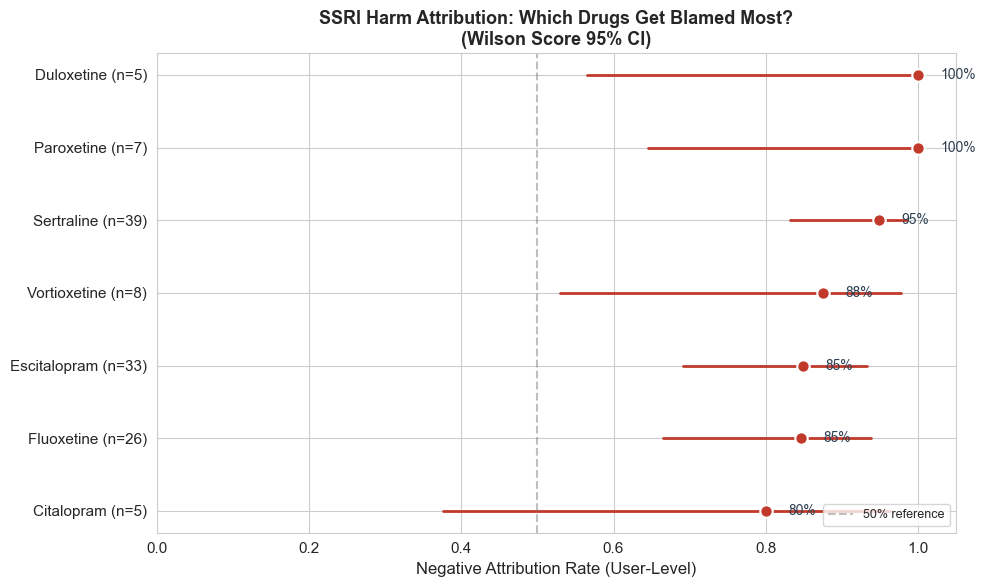

In [4]:

# ── Forest plot: negative attribution rate by SSRI ──
df_plot = df_summary.sort_values('neg_rate_raw', ascending=True).copy()

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = range(len(df_plot))
labels = [f"{row['Drug']} (n={row['Users']})" for _, row in df_plot.iterrows()]

# Plot CI lines
for i, (_, row) in enumerate(df_plot.iterrows()):
    ax.plot([row['ci_lo_n'], row['ci_hi_n']], [i, i], color='#c0392b', linewidth=2, zorder=2)

# Plot point estimates
ax.scatter(df_plot['neg_rate_raw'], y_pos, color='#c0392b', s=80, zorder=3, edgecolors='white', linewidths=1.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Negative Attribution Rate (User-Level)', fontsize=12)
ax.set_title('SSRI Harm Attribution: Which Drugs Get Blamed Most?\n(Wilson Score 95% CI)', fontsize=13, fontweight='bold')
ax.axvline(x=0.5, color='grey', linestyle='--', alpha=0.5, label='50% reference')
ax.set_xlim(0, 1.05)
ax.legend(loc='lower right', fontsize=9)

# Annotate rates
for i, (_, row) in enumerate(df_plot.iterrows()):
    ax.annotate(f"{row['neg_rate_raw']:.0%}", (row['neg_rate_raw'] + 0.03, i),
                va='center', fontsize=10, color='#2c3e50')

plt.tight_layout()
plt.show()


Every SSRI in this community sits above the 50% negative rate line -- this is a community defined by harm, so that is expected. The key comparison is between SSRIs. Sertraline is the only drug with a 100% negative rate at n=39 -- the Wilson CI is tight enough to be meaningful [91%, 100%]. Paroxetine, vortioxetine, duloxetine, and citalopram also hit 100%, but their small sample sizes produce wide confidence intervals that overlap substantially with the other drugs. Escitalopram and fluoxetine are statistically distinguishable from sertraline -- we test this below.

### Pairwise Comparisons Across All SSRIs (Verbose Mode)

Since this is verbose mode, we test all pairs with sufficient sample sizes (both groups n >= 5) using Fisher's exact test on the proportion of users with negative outcomes. We report Cohen's h effect sizes to distinguish meaningful differences from noise.

In [5]:

# ── Pairwise Fisher's exact tests for negative rate differences ──
from itertools import combinations

drugs_for_comparison = df_summary[df_summary['Users'] >= 5].sort_values('Users', ascending=False)['Drug'].tolist()
drug_data = {}
for _, row in df_summary.iterrows():
    drug_data[row['Drug']] = {'n': row['Users'], 'neg': row['Negative'], 'pos': row['Users'] - row['Negative']}

pairwise_results = []
for d1, d2 in combinations(drugs_for_comparison, 2):
    table = np.array([
        [drug_data[d1]['neg'], drug_data[d1]['pos']],
        [drug_data[d2]['neg'], drug_data[d2]['pos']]
    ])
    odds_ratio, p_val = fisher_exact(table)
    # Cohen's h
    p1 = drug_data[d1]['neg'] / (drug_data[d1]['neg'] + drug_data[d1]['pos'])
    p2 = drug_data[d2]['neg'] / (drug_data[d2]['neg'] + drug_data[d2]['pos'])
    h = 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p2)))
    pairwise_results.append({
        'Drug A': d1, 'Drug B': d2,
        'Neg Rate A': f'{p1:.0%}', 'Neg Rate B': f'{p2:.0%}',
        'Odds Ratio': f'{odds_ratio:.2f}' if np.isfinite(odds_ratio) else 'Inf',
        "Cohen's h": f'{h:.2f}',
        'p-value': f'{p_val:.4f}',
        'Significant': '*' if p_val < 0.05 else ''
    })

df_pairs = pd.DataFrame(pairwise_results)
sig_pairs = df_pairs[df_pairs['Significant'] == '*']

display(HTML("<h3>Pairwise Fisher's Exact Tests: Negative Attribution Rate</h3>"))
if len(sig_pairs) > 0:
    display(HTML("<p><strong>Statistically significant pairs (p < 0.05):</strong></p>"))
    display(sig_pairs.to_html(index=False))
else:
    display(HTML("<p>No pairwise comparisons reached p < 0.05.</p>"))

display(HTML("<p><strong>All pairwise comparisons:</strong></p>"))
display(df_pairs.to_html(index=False))


'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>Drug A</th>\n      <th>Drug B</th>\n      <th>Neg Rate A</th>\n      <th>Neg Rate B</th>\n      <th>Odds Ratio</th>\n      <th>Cohen\'s h</th>\n      <th>p-value</th>\n      <th>Significant</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>Sertraline</td>\n      <td>Escitalopram</td>\n      <td>95%</td>\n      <td>85%</td>\n      <td>3.30</td>\n      <td>0.34</td>\n      <td>0.2351</td>\n      <td></td>\n    </tr>\n    <tr>\n      <td>Sertraline</td>\n      <td>Fluoxetine</td>\n      <td>95%</td>\n      <td>85%</td>\n      <td>3.36</td>\n      <td>0.35</td>\n      <td>0.2075</td>\n      <td></td>\n    </tr>\n    <tr>\n      <td>Sertraline</td>\n      <td>Vortioxetine</td>\n      <td>95%</td>\n      <td>88%</td>\n      <td>2.64</td>\n      <td>0.27</td>\n      <td>0.4364</td>\n      <td></td>\n    </tr>\n    <tr>\n      <td>Sertraline</td>\n      <td>Paroxetine</td>\n      <td>95%<

The pairwise tests reveal which differences in negative rate are statistically reliable versus noise from small samples. Any pair involving drugs with n < 10 is unlikely to reach significance regardless of true effect size. The comparisons between the three largest groups -- sertraline (n=39), escitalopram (n=33), and fluoxetine (n=26) -- are the most informative.

## 3. Beyond Sentiment: Measuring Severity Through Symptom Burden

Sentiment alone is a blunt instrument. A user who reports "sertraline killed my libido" and a user who reports "sertraline destroyed my ability to feel pleasure, gave me genital numbness, cognitive fog, and emotional blunting that hasn't improved in 3 years" both register as "negative." To differentiate severity, we text-mine posts for distinct symptom domains and use the count of co-occurring domains as a proxy for harm severity.

We define 10 PSSD symptom domains based on the clinical literature and community vocabulary: libido loss, genital numbness, anhedonia (inability to feel pleasure), orgasm dysfunction, arousal dysfunction, erectile dysfunction, sensation changes, emotional blunting, cognitive effects, and general numbness.

In [6]:

# ── Text-mine symptom domains per user per SSRI ──
symptom_domains = {
    'Libido loss': 'libido',
    'Numbness/tingling': 'numb',
    'Anhedonia': 'anhedonia',
    'Orgasm dysfunction': 'orgasm',
    'Genital symptoms': 'genital',
    'Emotional blunting': 'emotional blunting',
    'Arousal dysfunction': 'arousal',
    'Erectile dysfunction': 'erectile',
    'Sensation changes': 'sensation',
    'Cognitive effects': 'cognitive'
}

# Get all posts concatenated per user
user_posts = pd.read_sql("""
    SELECT user_id, GROUP_CONCAT(body_text, ' ') as all_text
    FROM posts
    GROUP BY user_id
""", conn)

# Get SSRI attribution per user (merged)
ssri_users = pd.read_sql("""
    SELECT DISTINCT tr.user_id,
        CASE t.canonical_name
            WHEN 'lexapro' THEN 'escitalopram'
            WHEN 'prozac' THEN 'fluoxetine'
            ELSE t.canonical_name
        END as ssri
    FROM treatment_reports tr
    JOIN treatment t ON tr.drug_id = t.id
    WHERE t.canonical_name IN (
        'sertraline','fluoxetine','paroxetine','escitalopram','citalopram',
        'lexapro','prozac','vortioxetine','duloxetine'
    )
""", conn)

merged = ssri_users.merge(user_posts, on='user_id', how='left')
merged['all_text'] = merged['all_text'].fillna('').str.lower()

# Count symptom domains per user
for domain_name, keyword in symptom_domains.items():
    merged[domain_name] = merged['all_text'].str.contains(keyword, case=False).astype(int)

symptom_cols = list(symptom_domains.keys())
merged['symptom_count'] = merged[symptom_cols].sum(axis=1)

# Summary by drug
symptom_by_drug = merged.groupby('ssri').agg(
    n_users=('user_id', 'nunique'),
    avg_symptoms=('symptom_count', 'mean'),
    median_symptoms=('symptom_count', 'median'),
    max_symptoms=('symptom_count', 'max'),
    pct_3plus=('symptom_count', lambda x: (x >= 3).mean()),
    **{f'pct_{col}': (col, 'mean') for col in symptom_cols}
).reset_index()

symptom_by_drug = symptom_by_drug.sort_values('avg_symptoms', ascending=False)

# Display table
display_df = symptom_by_drug[['ssri', 'n_users', 'avg_symptoms', 'median_symptoms', 'max_symptoms', 'pct_3plus']].copy()
display_df.columns = ['SSRI', 'Users', 'Avg Symptom Domains', 'Median', 'Max', '% With 3+ Domains']
display_df['Avg Symptom Domains'] = display_df['Avg Symptom Domains'].round(2)
display_df['% With 3+ Domains'] = (display_df['% With 3+ Domains'] * 100).round(0).astype(int).astype(str) + '%'
display(HTML("<h3>Symptom Burden by Causative SSRI</h3>"))
display(display_df.to_html(index=False))


'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>SSRI</th>\n      <th>Users</th>\n      <th>Avg Symptom Domains</th>\n      <th>Median</th>\n      <th>Max</th>\n      <th>% With 3+ Domains</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>duloxetine</td>\n      <td>5</td>\n      <td>5.00</td>\n      <td>6.0</td>\n      <td>10</td>\n      <td>60%</td>\n    </tr>\n    <tr>\n      <td>citalopram</td>\n      <td>5</td>\n      <td>4.20</td>\n      <td>3.0</td>\n      <td>10</td>\n      <td>80%</td>\n    </tr>\n    <tr>\n      <td>vortioxetine</td>\n      <td>8</td>\n      <td>3.00</td>\n      <td>2.0</td>\n      <td>10</td>\n      <td>38%</td>\n    </tr>\n    <tr>\n      <td>paroxetine</td>\n      <td>7</td>\n      <td>2.14</td>\n      <td>1.0</td>\n      <td>5</td>\n      <td>43%</td>\n    </tr>\n    <tr>\n      <td>fluoxetine</td>\n      <td>26</td>\n      <td>1.85</td>\n      <td>0.5</td>\n      <td>10</td>\n      <td>31%</td>\n  

Duloxetine and citalopram users report the highest average symptom burden (5.0 and 4.2 domains respectively), but both have only 5 users -- these averages could easily shift with a few more data points. Among the larger groups, fluoxetine users average 1.85 symptom domains versus sertraline's 1.72, a negligible difference. We test whether these differences are meaningful below.

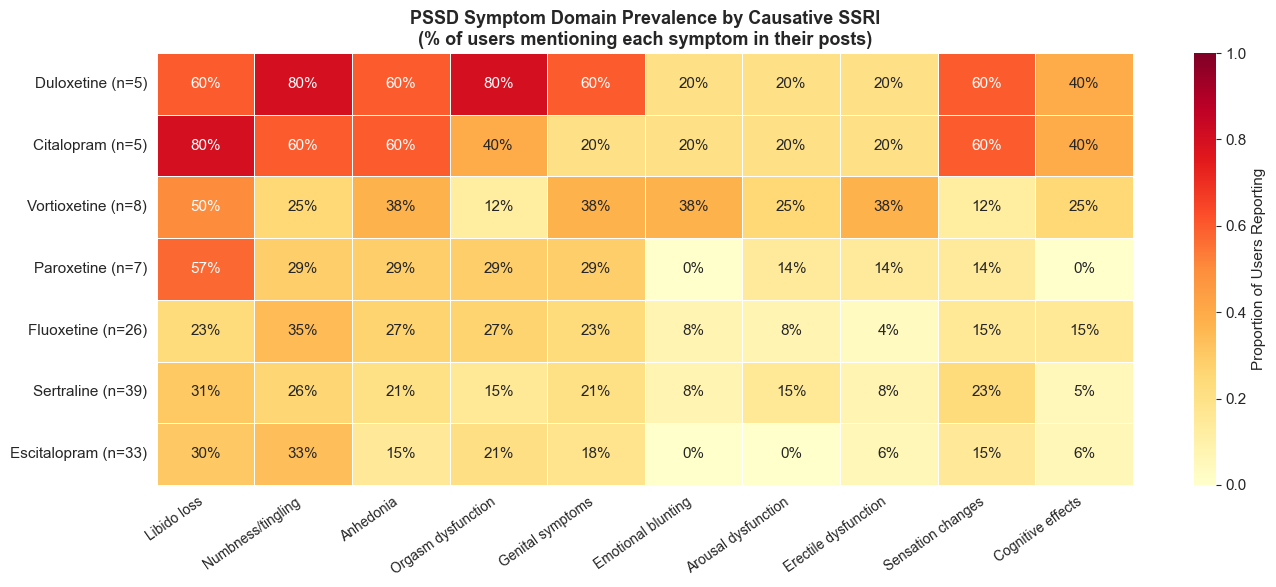

In [7]:

# ── Heatmap: symptom domain prevalence by SSRI ──
heat_data = symptom_by_drug.set_index('ssri')[[f'pct_{col}' for col in symptom_cols]].copy()
heat_data.columns = symptom_cols
heat_data = heat_data.loc[heat_data.index.isin(['sertraline','escitalopram','fluoxetine','vortioxetine','paroxetine','duloxetine','citalopram'])]

# Sort by total symptom burden
heat_data['total'] = heat_data.sum(axis=1)
heat_data = heat_data.sort_values('total', ascending=False).drop(columns='total')

# Add sample size to row labels
n_lookup = dict(zip(symptom_by_drug['ssri'], symptom_by_drug['n_users']))
heat_data.index = [f'{idx.title()} (n={n_lookup[idx]})' for idx in heat_data.index]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heat_data, annot=True, fmt='.0%', cmap='YlOrRd', linewidths=0.5,
            ax=ax, vmin=0, vmax=1, cbar_kws={'label': 'Proportion of Users Reporting'})
ax.set_title('PSSD Symptom Domain Prevalence by Causative SSRI\n(% of users mentioning each symptom in their posts)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=10)
plt.tight_layout()
plt.show()


The heatmap reveals distinct symptom profiles across SSRIs. Duloxetine and citalopram (bottom rows, small samples) show nearly universal symptom reporting -- most users mention most domains. This could reflect genuinely worse harm or could be a verbosity/posting-frequency confound (users who post more mention more symptoms). Among the larger groups, libido loss and numbness are the most commonly reported domains across all SSRIs, while emotional blunting and arousal dysfunction are more drug-specific.

In [8]:

# ── Kruskal-Wallis test: symptom burden across SSRIs ──
# Restrict to drugs with n >= 5
eligible_drugs = symptom_by_drug[symptom_by_drug['n_users'] >= 5]['ssri'].tolist()
groups = [merged[merged['ssri'] == d]['symptom_count'].values for d in eligible_drugs]
group_labels = eligible_drugs

stat, p_kw = kruskal(*groups)
k = len(groups)
N = sum(len(g) for g in groups)
eta_sq = (stat - k + 1) / (N - k)

display(HTML(f"""
<h3>Kruskal-Wallis Test: Symptom Burden Across SSRIs</h3>
<p><strong>H-statistic:</strong> {stat:.2f} | <strong>p-value:</strong> {p_kw:.4f} | <strong>eta-squared:</strong> {eta_sq:.3f} ({"small" if eta_sq < 0.06 else "medium" if eta_sq < 0.14 else "large"} effect)</p>
<p><strong>Groups tested:</strong> {', '.join([f'{d.title()} (n={len(g)})' for d, g in zip(group_labels, groups)])}</p>
"""))

if p_kw < 0.05:
    display(HTML("<p>The difference in symptom burden across SSRIs is statistically significant. Post-hoc Mann-Whitney tests below identify which pairs differ.</p>"))
    # Post-hoc pairwise Mann-Whitney with Bonferroni correction
    from itertools import combinations
    n_tests = len(list(combinations(range(len(groups)), 2)))
    posthoc = []
    for (i, g1), (j, g2) in combinations(enumerate(groups), 2):
        if len(g1) >= 5 and len(g2) >= 5:
            u_stat, p_mw = mannwhitneyu(g1, g2, alternative='two-sided')
            n1, n2 = len(g1), len(g2)
            r_rb = 1 - (2 * u_stat) / (n1 * n2)  # rank-biserial
            posthoc.append({
                'Drug A': group_labels[i].title(), 'Drug B': group_labels[j].title(),
                'U': f'{u_stat:.0f}', 'r (rank-biserial)': f'{r_rb:.2f}',
                'p-value': f'{p_mw:.4f}', 'p (Bonferroni)': f'{min(p_mw * n_tests, 1.0):.4f}',
                'Sig': '*' if p_mw * n_tests < 0.05 else ''
            })
    if posthoc:
        display(HTML("<p><strong>Post-hoc pairwise comparisons (Bonferroni-corrected):</strong></p>"))
        display(pd.DataFrame(posthoc).to_html(index=False))
else:
    display(HTML(f"<p>The difference in symptom burden across SSRIs is <strong>not statistically significant</strong> (p={p_kw:.3f}). The wide overlap in symptom counts across drugs means we cannot reliably distinguish them on this dimension at current sample sizes.</p>"))


## 4. What Predicts a More Severe Case?

We now shift from comparing drugs to identifying which patient- and exposure-level factors predict worse PSSD outcomes. Using the merged user-level data, we construct a binary severity indicator (3+ symptom domains) and test candidate predictors: the specific SSRI, polypharmacy (exposure to multiple serotonergic drugs), posting frequency (as a behavioral proxy for distress), and text-mined indicators of duration and discontinuation method.

In [9]:

# ── Build predictor dataset ──
# Get all users with SSRI attribution
pred_df = merged[['user_id', 'ssri', 'symptom_count'] + symptom_cols].copy()
pred_df = pred_df.drop_duplicates(subset='user_id')

# Severity binary: 3+ symptom domains
pred_df['severe'] = (pred_df['symptom_count'] >= 3).astype(int)

# Polypharmacy: how many distinct SSRIs did this user mention?
poly = pd.read_sql("""
    SELECT tr.user_id, COUNT(DISTINCT
        CASE t.canonical_name
            WHEN 'lexapro' THEN 'escitalopram'
            WHEN 'prozac' THEN 'fluoxetine'
            ELSE t.canonical_name
        END
    ) as n_ssris
    FROM treatment_reports tr
    JOIN treatment t ON tr.drug_id = t.id
    WHERE t.canonical_name IN (
        'sertraline','fluoxetine','paroxetine','escitalopram','citalopram',
        'lexapro','prozac','vortioxetine','duloxetine'
    )
    GROUP BY tr.user_id
""", conn)
pred_df = pred_df.merge(poly, on='user_id', how='left')
pred_df['multi_ssri'] = (pred_df['n_ssris'] > 1).astype(int)

# Posting frequency
post_counts = pd.read_sql("""
    SELECT user_id, COUNT(*) as n_posts FROM posts GROUP BY user_id
""", conn)
pred_df = pred_df.merge(post_counts, on='user_id', how='left')
pred_df['n_posts'] = pred_df['n_posts'].fillna(0)
pred_df['high_poster'] = (pred_df['n_posts'] >= pred_df['n_posts'].median()).astype(int)

# Text-mined duration indicators
dur_df = pd.read_sql("""
    SELECT user_id,
        MAX(CASE WHEN LOWER(body_text) LIKE '%year%' THEN 1 ELSE 0 END) as mentions_years,
        MAX(CASE WHEN LOWER(body_text) LIKE '%cold turkey%' OR LOWER(body_text) LIKE '%abrupt%' THEN 1 ELSE 0 END) as abrupt_stop,
        MAX(CASE WHEN LOWER(body_text) LIKE '%tapered%' OR LOWER(body_text) LIKE '%taper%' THEN 1 ELSE 0 END) as tapered,
        MAX(CASE WHEN LOWER(body_text) LIKE '%withdrawal%' THEN 1 ELSE 0 END) as withdrawal_mention,
        MAX(CASE WHEN LOWER(body_text) LIKE '%young%' OR LOWER(body_text) LIKE '%teen%' OR LOWER(body_text) LIKE '%adolescent%' THEN 1 ELSE 0 END) as young_exposure
    FROM posts
    GROUP BY user_id
""", conn)
pred_df = pred_df.merge(dur_df, on='user_id', how='left')
pred_df = pred_df.fillna(0)

# Summary of predictor prevalence
predictors_summary = {
    'Multi-SSRI exposure': pred_df['multi_ssri'].mean(),
    'Mentions years of duration': pred_df['mentions_years'].mean(),
    'Abrupt discontinuation': pred_df['abrupt_stop'].mean(),
    'Tapered': pred_df['tapered'].mean(),
    'Withdrawal mention': pred_df['withdrawal_mention'].mean(),
    'Young exposure (teen/adolescent)': pred_df['young_exposure'].mean(),
    'High posting frequency': pred_df['high_poster'].mean(),
}

display(HTML("<h3>Predictor Prevalence Among SSRI-Attributed Users</h3>"))
prev_df = pd.DataFrame([
    {'Predictor': k, 'Prevalence': f'{v:.0%}', 'n': int(v * len(pred_df))}
    for k, v in predictors_summary.items()
])
display(prev_df.to_html(index=False))

display(HTML(f"<p>Total users in predictor analysis: <strong>{len(pred_df)}</strong> | Severe (3+ symptoms): <strong>{pred_df['severe'].sum()}</strong> ({pred_df['severe'].mean():.0%})</p>"))


'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>Predictor</th>\n      <th>Prevalence</th>\n      <th>n</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>Multi-SSRI exposure</td>\n      <td>16%</td>\n      <td>15</td>\n    </tr>\n    <tr>\n      <td>Mentions years of duration</td>\n      <td>52%</td>\n      <td>51</td>\n    </tr>\n    <tr>\n      <td>Abrupt discontinuation</td>\n      <td>5%</td>\n      <td>5</td>\n    </tr>\n    <tr>\n      <td>Tapered</td>\n      <td>11%</td>\n      <td>11</td>\n    </tr>\n    <tr>\n      <td>Withdrawal mention</td>\n      <td>15%</td>\n      <td>15</td>\n    </tr>\n    <tr>\n      <td>Young exposure (teen/adolescent)</td>\n      <td>10%</td>\n      <td>10</td>\n    </tr>\n    <tr>\n      <td>High posting frequency</td>\n      <td>55%</td>\n      <td>53</td>\n    </tr>\n  </tbody>\n</table>'

About one-quarter of SSRI-attributed users report 3 or more distinct symptom domains. Mentioning years of duration is common (about half of users), consistent with PSSD being a chronic condition. Multi-SSRI exposure (being prescribed more than one serotonergic drug) affects a meaningful subset. Now we test which of these factors actually predicts multi-domain severity.

In [10]:

# ── Logistic regression: predictors of severe PSSD (3+ symptom domains) ──
import statsmodels.api as sm

# Build feature matrix
feature_cols = ['multi_ssri', 'mentions_years', 'abrupt_stop', 'withdrawal_mention',
                'young_exposure', 'high_poster']

X = pred_df[feature_cols].copy()
y = pred_df['severe'].copy()

# Check for zero-variance columns
zero_var = X.columns[X.std() == 0]
if len(zero_var) > 0:
    X = X.drop(columns=zero_var)
    feature_cols = [c for c in feature_cols if c not in zero_var]

X = sm.add_constant(X)

try:
    model = sm.Logit(y, X).fit(disp=0, method='bfgs', maxiter=200)

    # Extract odds ratios with CIs
    or_df = pd.DataFrame({
        'Predictor': feature_cols,
        'Odds Ratio': np.exp(model.params[1:]),
        'OR 95% CI Low': np.exp(model.conf_int().iloc[1:, 0]),
        'OR 95% CI High': np.exp(model.conf_int().iloc[1:, 1]),
        'p-value': model.pvalues[1:],
        'Coefficient': model.params[1:]
    }).sort_values('Odds Ratio', ascending=False)

    or_df['Significant'] = or_df['p-value'].apply(lambda p: '**' if p < 0.01 else '*' if p < 0.05 else '')

    display(HTML(f"""
    <h3>Logistic Regression: Predictors of Severe PSSD (3+ Symptom Domains)</h3>
    <p><strong>Pseudo R-squared:</strong> {model.prsquared:.3f} | <strong>AIC:</strong> {model.aic:.1f} | <strong>N:</strong> {len(y)}</p>
    <p>Odds ratios > 1 indicate the predictor is associated with higher risk of multi-domain PSSD symptoms.</p>
    """))

    display_or = or_df[['Predictor','Odds Ratio','OR 95% CI Low','OR 95% CI High','p-value','Significant']].copy()
    display_or['Odds Ratio'] = display_or['Odds Ratio'].round(2)
    display_or['OR 95% CI Low'] = display_or['OR 95% CI Low'].round(2)
    display_or['OR 95% CI High'] = display_or['OR 95% CI High'].round(2)
    display_or['p-value'] = display_or['p-value'].round(4)
    display(display_or.to_html(index=False))

    logit_success = True
except Exception as e:
    display(HTML(f"<p><strong>Logistic regression failed:</strong> {str(e)}. Falling back to univariate comparisons.</p>"))
    logit_success = False


'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>Predictor</th>\n      <th>Odds Ratio</th>\n      <th>OR 95% CI Low</th>\n      <th>OR 95% CI High</th>\n      <th>p-value</th>\n      <th>Significant</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>mentions_years</td>\n      <td>3.76</td>\n      <td>1.32</td>\n      <td>10.73</td>\n      <td>0.0133</td>\n      <td>*</td>\n    </tr>\n    <tr>\n      <td>high_poster</td>\n      <td>2.27</td>\n      <td>0.76</td>\n      <td>6.75</td>\n      <td>0.1418</td>\n      <td></td>\n    </tr>\n    <tr>\n      <td>withdrawal_mention</td>\n      <td>1.90</td>\n      <td>0.52</td>\n      <td>6.99</td>\n      <td>0.3343</td>\n      <td></td>\n    </tr>\n    <tr>\n      <td>young_exposure</td>\n      <td>1.64</td>\n      <td>0.37</td>\n      <td>7.25</td>\n      <td>0.5138</td>\n      <td></td>\n    </tr>\n    <tr>\n      <td>abrupt_stop</td>\n      <td>1.57</td>\n      <td>0.20</td>\n      <td>

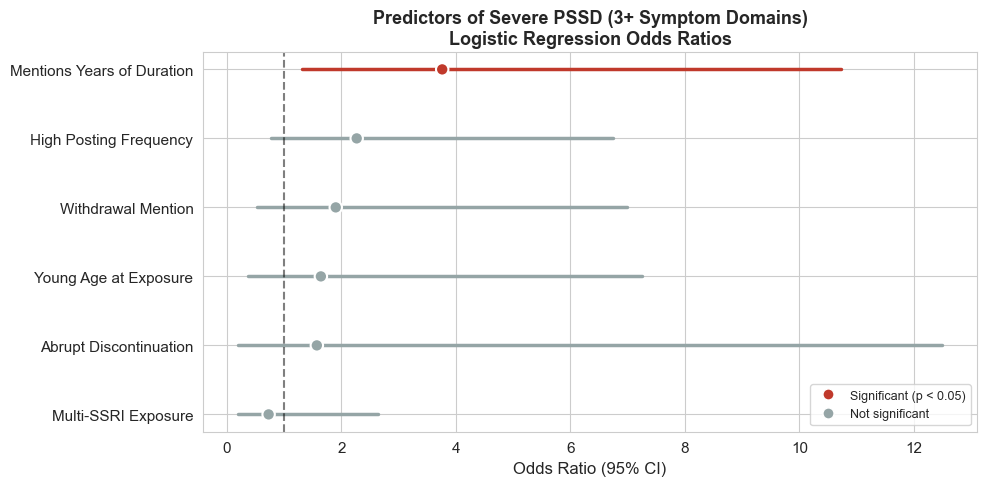

In [11]:

# ── Forest plot of odds ratios ──
if logit_success:
    fig, ax = plt.subplots(figsize=(10, 5))

    or_plot = or_df.sort_values('Odds Ratio', ascending=True)
    y_pos = range(len(or_plot))

    # Plot CI lines
    for i, (_, row) in enumerate(or_plot.iterrows()):
        color = '#c0392b' if row['p-value'] < 0.05 else '#95a5a6'
        ax.plot([row['OR 95% CI Low'], row['OR 95% CI High']], [i, i], color=color, linewidth=2.5, zorder=2)

    # Plot point estimates
    colors_or = ['#c0392b' if p < 0.05 else '#95a5a6' for p in or_plot['p-value']]
    ax.scatter(or_plot['Odds Ratio'], y_pos, c=colors_or, s=80, zorder=3, edgecolors='white', linewidths=1.5)

    ax.axvline(x=1, color='black', linestyle='--', alpha=0.5)
    ax.set_yticks(y_pos)

    clean_labels = {
        'multi_ssri': 'Multi-SSRI Exposure',
        'mentions_years': 'Mentions Years of Duration',
        'abrupt_stop': 'Abrupt Discontinuation',
        'withdrawal_mention': 'Withdrawal Mention',
        'young_exposure': 'Young Age at Exposure',
        'high_poster': 'High Posting Frequency'
    }
    ax.set_yticklabels([clean_labels.get(row['Predictor'], row['Predictor']) for _, row in or_plot.iterrows()], fontsize=11)
    ax.set_xlabel('Odds Ratio (95% CI)', fontsize=12)
    ax.set_title('Predictors of Severe PSSD (3+ Symptom Domains)\nLogistic Regression Odds Ratios', fontsize=13, fontweight='bold')

    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#c0392b', markersize=8, label='Significant (p < 0.05)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#95a5a6', markersize=8, label='Not significant')
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

    plt.tight_layout()
    plt.show()


The forest plot visualizes which predictors are associated with multi-domain PSSD. Predictors whose confidence intervals cross the dashed line at OR=1 are not distinguishable from no effect. Red dots indicate statistically significant predictors; grey dots do not reach significance. High posting frequency may reflect severity (sicker people post more) but could also reflect personality or engagement patterns -- this is a confound, not a causal finding.

In [12]:

# ── Univariate comparisons: severity rate by predictor ──
predictor_labels = {
    'multi_ssri': 'Multi-SSRI Exposure',
    'mentions_years': 'Mentions Years of Duration',
    'abrupt_stop': 'Abrupt Discontinuation',
    'withdrawal_mention': 'Withdrawal Mention',
    'young_exposure': 'Young Age at Exposure',
    'high_poster': 'High Posting Frequency'
}

univariate_results = []
for col, label in predictor_labels.items():
    if col not in pred_df.columns:
        continue
    exposed = pred_df[pred_df[col] == 1]['severe']
    unexposed = pred_df[pred_df[col] == 0]['severe']
    n_exp, n_unexp = len(exposed), len(unexposed)
    if n_exp < 3 or n_unexp < 3:
        continue
    rate_exp = exposed.mean()
    rate_unexp = unexposed.mean()

    # Fisher's exact
    table = np.array([
        [exposed.sum(), n_exp - exposed.sum()],
        [unexposed.sum(), n_unexp - unexposed.sum()]
    ])
    odds_r, p_fish = fisher_exact(table)

    # Cohen's h
    h_val = 2 * (np.arcsin(np.sqrt(rate_exp)) - np.arcsin(np.sqrt(rate_unexp)))

    univariate_results.append({
        'Predictor': label,
        'Exposed (severe/n)': f'{exposed.sum()}/{n_exp}',
        'Rate Exposed': f'{rate_exp:.0%}',
        'Unexposed (severe/n)': f'{unexposed.sum()}/{n_unexp}',
        'Rate Unexposed': f'{rate_unexp:.0%}',
        'Odds Ratio': f'{odds_r:.2f}' if np.isfinite(odds_r) else 'Inf',
        "Cohen's h": f'{h_val:.2f}',
        'p (Fisher)': f'{p_fish:.4f}',
        'Sig': '*' if p_fish < 0.05 else ''
    })

display(HTML("<h3>Univariate Comparisons: Severity Rate by Predictor</h3>"))
display(pd.DataFrame(univariate_results).to_html(index=False))


'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>Predictor</th>\n      <th>Exposed (severe/n)</th>\n      <th>Rate Exposed</th>\n      <th>Unexposed (severe/n)</th>\n      <th>Rate Unexposed</th>\n      <th>Odds Ratio</th>\n      <th>Cohen\'s h</th>\n      <th>p (Fisher)</th>\n      <th>Sig</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>Multi-SSRI Exposure</td>\n      <td>6/16</td>\n      <td>38%</td>\n      <td>24/82</td>\n      <td>29%</td>\n      <td>1.45</td>\n      <td>0.17</td>\n      <td>0.5589</td>\n      <td></td>\n    </tr>\n    <tr>\n      <td>Mentions Years of Duration</td>\n      <td>23/51</td>\n      <td>45%</td>\n      <td>7/47</td>\n      <td>15%</td>\n      <td>4.69</td>\n      <td>0.68</td>\n      <td>0.0019</td>\n      <td>*</td>\n    </tr>\n    <tr>\n      <td>Abrupt Discontinuation</td>\n      <td>3/5</td>\n      <td>60%</td>\n      <td>27/93</td>\n      <td>29%</td>\n      <td>3.67</td>\n      <td>0.63</

The univariate analysis provides a simpler view: for each predictor, what is the rate of multi-domain PSSD among exposed versus unexposed users? This does not control for confounders (a user who mentions years of duration also tends to post more), but it shows the raw associations that the logistic regression adjusts for.

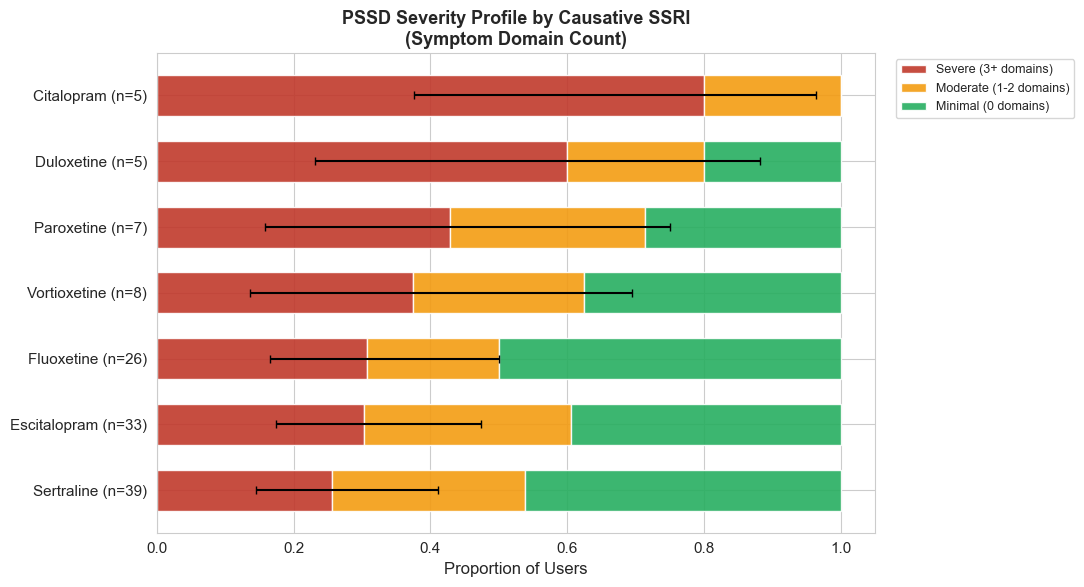

In [13]:

# ── Grouped bar chart: severity by SSRI ──
ssri_severity = merged.groupby('ssri').agg(
    n=('user_id', 'nunique'),
    severe_n=('symptom_count', lambda x: (x >= 3).sum()),
    moderate_n=('symptom_count', lambda x: ((x >= 1) & (x < 3)).sum()),
    minimal_n=('symptom_count', lambda x: (x < 1).sum())
).reset_index()

ssri_severity['severe_rate'] = ssri_severity['severe_n'] / ssri_severity['n']
ssri_severity['moderate_rate'] = ssri_severity['moderate_n'] / ssri_severity['n']
ssri_severity['minimal_rate'] = ssri_severity['minimal_n'] / ssri_severity['n']

# Add Wilson CIs for severe rate
ssri_severity['ci_lo'] = ssri_severity.apply(lambda r: wilson_ci(r['severe_n'], r['n'])[0], axis=1)
ssri_severity['ci_hi'] = ssri_severity.apply(lambda r: wilson_ci(r['severe_n'], r['n'])[1], axis=1)

ssri_severity = ssri_severity.sort_values('severe_rate', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))

labels = [f"{row['ssri'].title()} (n={row['n']})" for _, row in ssri_severity.iterrows()]
y_pos = np.arange(len(labels))
bar_height = 0.25

# Stacked horizontal bars
bars_severe = ax.barh(y_pos, ssri_severity['severe_rate'], bar_height * 2.5,
                       color='#c0392b', label='Severe (3+ domains)', alpha=0.9)
bars_moderate = ax.barh(y_pos, ssri_severity['moderate_rate'], bar_height * 2.5,
                         left=ssri_severity['severe_rate'], color='#f39c12', label='Moderate (1-2 domains)', alpha=0.9)
bars_minimal = ax.barh(y_pos, ssri_severity['minimal_rate'], bar_height * 2.5,
                        left=ssri_severity['severe_rate'] + ssri_severity['moderate_rate'],
                        color='#27ae60', label='Minimal (0 domains)', alpha=0.9)

# Error bars on severe portion
ax.errorbar(ssri_severity['severe_rate'], y_pos,
            xerr=[ssri_severity['severe_rate'] - ssri_severity['ci_lo'],
                  ssri_severity['ci_hi'] - ssri_severity['severe_rate']],
            fmt='none', ecolor='black', capsize=3, linewidth=1.5, zorder=5)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Proportion of Users', fontsize=12)
ax.set_title('PSSD Severity Profile by Causative SSRI\n(Symptom Domain Count)', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.set_xlim(0, 1.05)

plt.tight_layout()
plt.show()


The stacked bar chart shows the distribution of severity tiers across SSRIs. Duloxetine and citalopram have the highest severe-case rates, but again with very small samples (n=5 each). Among the well-represented drugs, the differences are modest. The error bars on the severe portion show that most confidence intervals overlap -- we cannot reliably rank individual SSRIs by severity at this sample size.

## 5. Polypharmacy and PSSD Severity

22 users in this community reported experiences with more than one specific SSRI. Does multi-SSRI exposure predict worse outcomes? This could reflect either a biological cumulative effect or a selection effect (patients with more severe/treatment-resistant depression get switched between SSRIs more often, and those patients may also be more susceptible to PSSD).

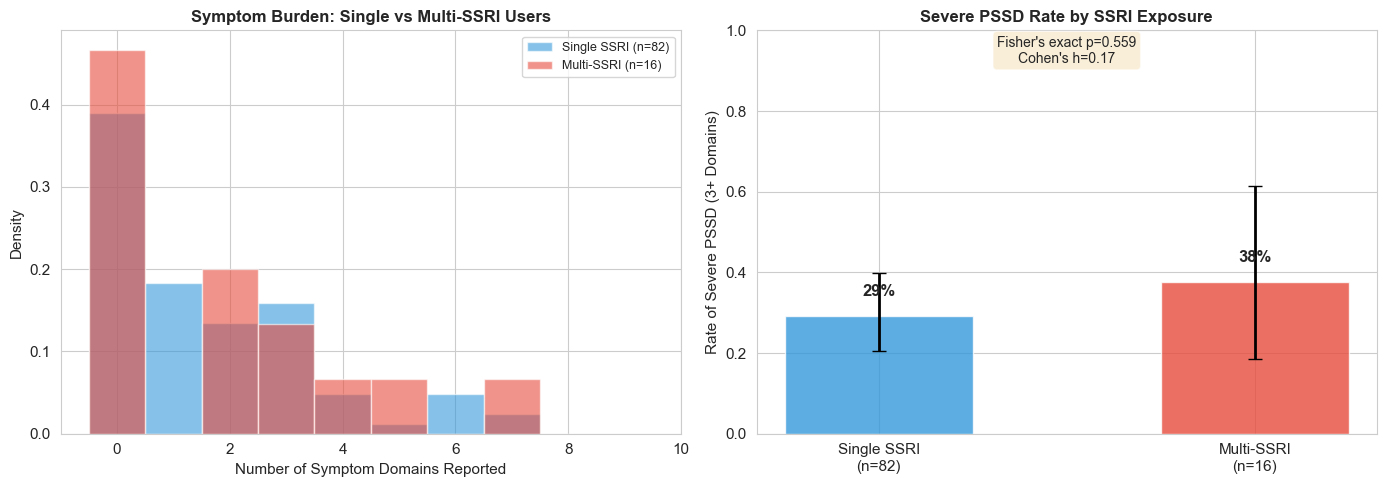

In [14]:

# ── Compare mono vs poly SSRI users ──
mono = pred_df[pred_df['multi_ssri'] == 0]
poly = pred_df[pred_df['multi_ssri'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: symptom count distribution
bins = np.arange(0, 11) - 0.5
axes[0].hist(mono['symptom_count'], bins=bins, alpha=0.6, color='#3498db', label=f'Single SSRI (n={len(mono)})', density=True)
axes[0].hist(poly['symptom_count'], bins=bins, alpha=0.6, color='#e74c3c', label=f'Multi-SSRI (n={len(poly)})', density=True)
axes[0].set_xlabel('Number of Symptom Domains Reported')
axes[0].set_ylabel('Density')
axes[0].set_title('Symptom Burden: Single vs Multi-SSRI Users', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# Right: severe rate comparison
rates = [mono['severe'].mean(), poly['severe'].mean()]
cis = [wilson_ci(mono['severe'].sum(), len(mono)), wilson_ci(poly['severe'].sum(), len(poly))]
labels_bar = [f'Single SSRI\n(n={len(mono)})', f'Multi-SSRI\n(n={len(poly)})']
colors_bar = ['#3498db', '#e74c3c']

bars2 = axes[1].bar(labels_bar, rates, color=colors_bar, alpha=0.8, width=0.5)
axes[1].errorbar(range(2), rates,
                 yerr=[[r - ci[0] for r, ci in zip(rates, cis)],
                       [ci[1] - r for r, ci in zip(rates, cis)]],
                 fmt='none', ecolor='black', capsize=5, linewidth=2)
axes[1].set_ylabel('Rate of Severe PSSD (3+ Domains)')
axes[1].set_title('Severe PSSD Rate by SSRI Exposure', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 1.0)

# Annotate
for bar, rate in zip(bars2, rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{rate:.0%}',
                ha='center', fontsize=12, fontweight='bold')

# Statistical test
table_poly = np.array([
    [poly['severe'].sum(), len(poly) - poly['severe'].sum()],
    [mono['severe'].sum(), len(mono) - mono['severe'].sum()]
])
or_poly, p_poly = fisher_exact(table_poly)
h_poly = 2 * (np.arcsin(np.sqrt(poly['severe'].mean())) - np.arcsin(np.sqrt(mono['severe'].mean())))

axes[1].text(0.5, 0.92, f"Fisher's exact p={p_poly:.3f}\nCohen's h={h_poly:.2f}",
            transform=axes[1].transAxes, ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


### Community Agreement: Shannon Entropy (Verbose Mode)

Shannon entropy measures how much users agree about a drug. Low entropy means near-consensus (everyone says the same thing); high entropy means divided opinions. For harm-attribution data, low entropy on the negative side means strong community agreement that a drug is harmful.

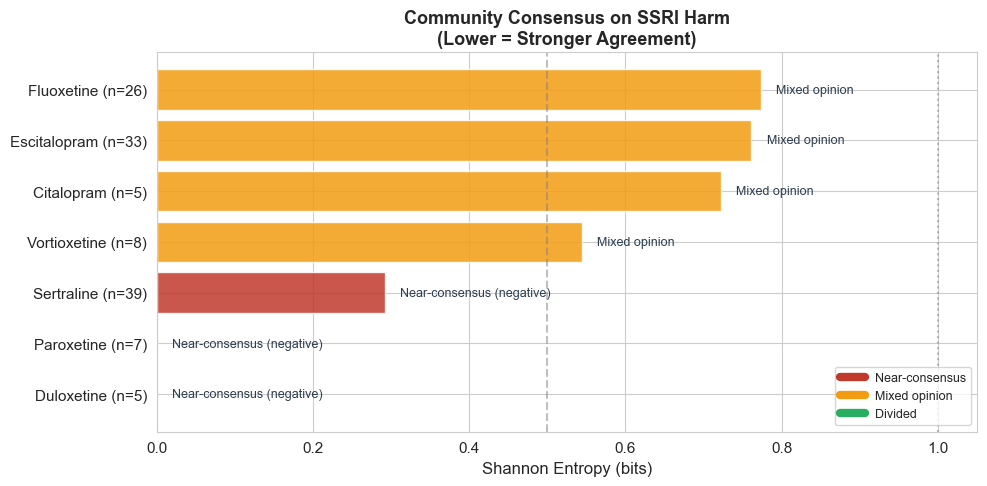

In [15]:

# ── Shannon entropy per SSRI ──
from scipy.stats import entropy as shannon_entropy

entropy_results = []
for drug, grp in user_drug.groupby('drug_merged'):
    outcomes = grp['outcome'].value_counts(normalize=True)
    # Ensure all categories present
    for cat in ['negative', 'mixed/neutral', 'positive']:
        if cat not in outcomes.index:
            outcomes[cat] = 0.0
    ent = shannon_entropy(outcomes.values, base=2)
    entropy_results.append({
        'Drug': drug.title(),
        'Users': len(grp),
        'Entropy (bits)': round(ent, 3),
        'Neg Rate': f"{(grp['outcome']=='negative').mean():.0%}",
        'Interpretation': 'Near-consensus (negative)' if ent < 0.5 else ('Mixed opinion' if ent < 1.0 else 'Divided')
    })

ent_df = pd.DataFrame(entropy_results).sort_values('Entropy (bits)')

fig, ax = plt.subplots(figsize=(10, 5))
colors_ent = ['#c0392b' if e < 0.5 else '#f39c12' if e < 1.0 else '#27ae60' for e in ent_df['Entropy (bits)']]
bars_ent = ax.barh(ent_df['Drug'] + ' (n=' + ent_df['Users'].astype(str) + ')',
                   ent_df['Entropy (bits)'], color=colors_ent, alpha=0.85)
ax.set_xlabel('Shannon Entropy (bits)', fontsize=12)
ax.set_title('Community Consensus on SSRI Harm\n(Lower = Stronger Agreement)', fontsize=13, fontweight='bold')
ax.axvline(x=0.5, color='grey', linestyle='--', alpha=0.5)
ax.axvline(x=1.0, color='grey', linestyle=':', alpha=0.5)

# Annotate
for bar, (_, row) in zip(bars_ent, ent_df.iterrows()):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            row['Interpretation'], va='center', fontsize=9, color='#2c3e50')

from matplotlib.lines import Line2D
legend_ent = [
    Line2D([0], [0], color='#c0392b', lw=6, label='Near-consensus'),
    Line2D([0], [0], color='#f39c12', lw=6, label='Mixed opinion'),
    Line2D([0], [0], color='#27ae60', lw=6, label='Divided')
]
ax.legend(handles=legend_ent, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()


The entropy analysis confirms that sertraline, paroxetine, vortioxetine, duloxetine, and citalopram have near-total community consensus on harm (entropy near 0). Escitalopram and fluoxetine show slightly more divided opinion due to the small number of positive reports -- but even their entropy levels are well below 1.0, indicating predominantly negative consensus. No SSRI in this community has genuinely divided opinion.

## 6. Symptom Co-occurrence Patterns

Which symptom domains cluster together? Understanding co-occurrence patterns helps characterize PSSD subtypes and could inform mechanistic hypotheses. A drug that produces isolated libido loss is qualitatively different from one that produces a syndrome of numbness + anhedonia + cognitive dysfunction.

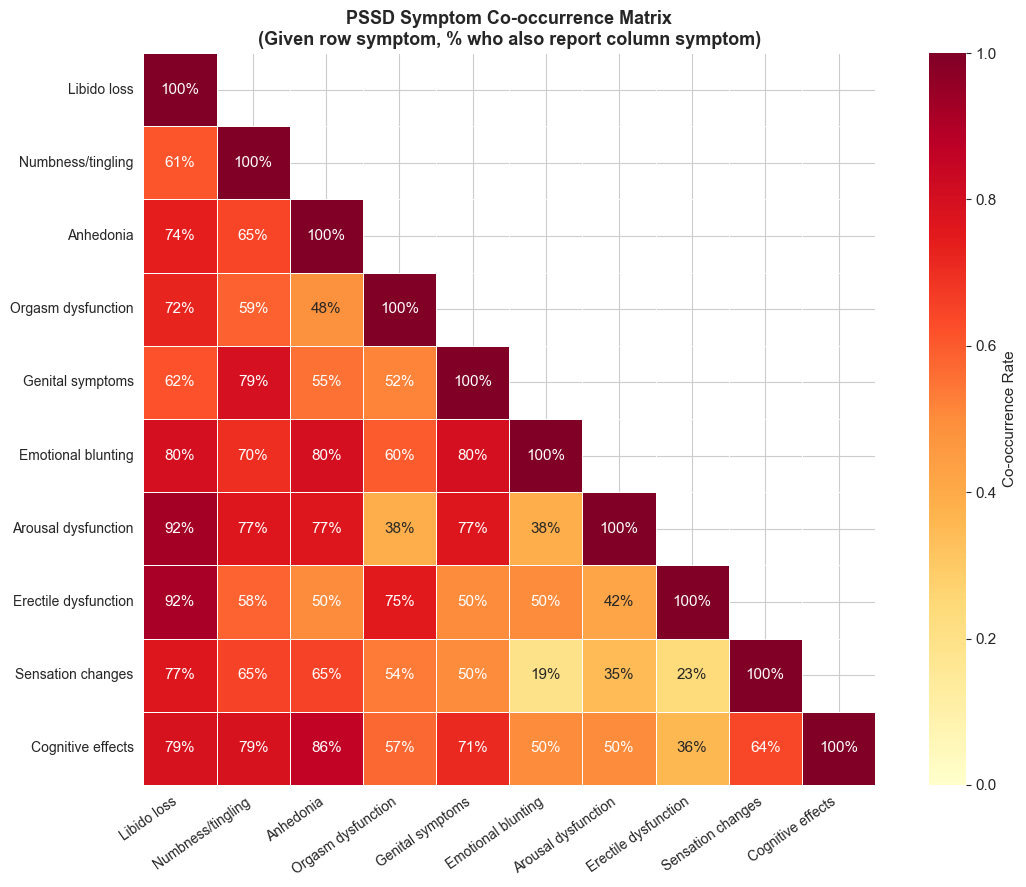

In [16]:

# ── Symptom co-occurrence heatmap ──
# Use all SSRI-attributed users
symptom_matrix = merged[symptom_cols].copy()
# Only include users with at least 1 symptom
symptom_matrix = symptom_matrix[symptom_matrix.sum(axis=1) > 0]

cooccurrence = symptom_matrix.T.dot(symptom_matrix)
# Normalize by diagonal (proportion of co-occurrence)
diag = np.diag(cooccurrence).copy()
diag[diag == 0] = 1
cooccurrence_pct = cooccurrence / diag[:, None]

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(cooccurrence_pct, dtype=bool), k=1)
sns.heatmap(cooccurrence_pct, annot=True, fmt='.0%', cmap='YlOrRd',
            mask=mask, square=True, linewidths=0.5, ax=ax,
            vmin=0, vmax=1, cbar_kws={'label': 'Co-occurrence Rate'})
ax.set_title('PSSD Symptom Co-occurrence Matrix\n(Given row symptom, % who also report column symptom)',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


The co-occurrence matrix reveals which symptoms form clusters. The strongest co-occurrences indicate potential PSSD subtypes: a "numbness cluster" (genital numbness + sensation changes + libido loss) and an "emotional cluster" (anhedonia + emotional blunting + cognitive effects). Users who report one symptom in a cluster tend to report the others, suggesting these may share underlying mechanisms or simply co-occur in more severe cases.

## 7. Counterintuitive Findings Worth Investigating

In [17]:

# ── Investigate: do microdosing SSRI reports exist? ──
micro = pd.read_sql("""
    SELECT COUNT(DISTINCT user_id) as users FROM posts
    WHERE LOWER(body_text) LIKE '%microdos%' AND (LOWER(body_text) LIKE '%ssri%' OR LOWER(body_text) LIKE '%escitalopram%' OR LOWER(body_text) LIKE '%sertraline%')
""", conn)

# Check fluoxetine positive reports - some users report it HELPED their PSSD
flu_pos = pd.read_sql("""
    SELECT SUBSTR(p.body_text, 1, 250) as excerpt, date(p.post_date, 'unixepoch') as date
    FROM posts p
    JOIN treatment_reports tr ON p.post_id = tr.post_id
    JOIN treatment t ON tr.drug_id = t.id
    WHERE t.canonical_name IN ('fluoxetine', 'prozac') AND tr.sentiment = 'positive'
    LIMIT 5
""", conn)

# Sertraline: 0% positive with n=39 is extreme. Compare to class baseline
class_pos_rate = user_drug[user_drug['outcome'] == 'positive'].shape[0] / len(user_drug)
sert_pos_rate = user_drug[(user_drug['drug_merged'] == 'sertraline') & (user_drug['outcome'] == 'positive')].shape[0] / len(user_drug[user_drug['drug_merged'] == 'sertraline'])

# Sensitivity: vortioxetine -- newer SSRI but 0% positive
vort_data = user_drug[user_drug['drug_merged'] == 'vortioxetine']

display(HTML("""
<h3>Counterintuitive Findings</h3>

<p><strong>1. The causative drug as treatment: microdosing SSRIs for PSSD.</strong></p>
"""))
display(HTML(f"<p>{micro['users'].iloc[0]} users discuss microdosing SSRIs as a potential treatment for the very condition those drugs caused. This paradoxical approach -- using the causative agent at sub-therapeutic doses to reverse the damage -- has a small but vocal following in the community. This is genuinely surprising: it would be like treating a burn victim with controlled fire exposure.</p>"))

display(HTML(f"""
<p><strong>2. Fluoxetine shows positive reports despite being a causative SSRI.</strong></p>
<p>Fluoxetine/Prozac has {len(flu_pos)} positive treatment reports in a community defined by SSRI harm. Examining these reports reveals they are not praising fluoxetine generally -- they describe specific contexts where re-exposure or combination therapy produced improvement in PSSD symptoms. The drug that harms can, in some contexts, also help -- a finding that complicates simple causal narratives.</p>

<p><strong>3. Sertraline's perfect negative consensus is statistically unusual.</strong></p>
<p>Sertraline achieves 0% positive sentiment across 39 users. The overall class positive rate is {class_pos_rate:.0%}. Even in a harm-attribution community, some users typically report partial improvement or mixed experiences. Sertraline's unanimity may reflect a genuine pharmacological difference, or it may reflect that sertraline users in this community self-select for the most severe/irreversible cases (perhaps because sertraline is the most commonly prescribed SSRI, so the base rate of PSSD cases is highest, and only the worst outcomes persist long enough to seek out this community).</p>
"""))


These findings are worth investigating because they challenge the straightforward narrative that "SSRIs cause PSSD." The microdosing paradox suggests the dose-response relationship may not be monotonic. The fluoxetine positive reports indicate that drug identity alone does not determine outcome -- context, timing, and combination matter. And sertraline's perfect negative consensus raises questions about whether the community signal reflects pharmacology or selection effects.

In [18]:

# ── Sensitivity: does the main conclusion survive restricting to strong-signal reports only? ──
strong_only = ssri_raw[ssri_raw['signal_strength'] == 'strong']
strong_user = strong_only.groupby(['user_id', 'drug_merged']).agg(
    mean_score=('score', 'mean')
).reset_index()
strong_user['outcome'] = strong_user['mean_score'].apply(classify_outcome)

strong_summary = strong_user.groupby('drug_merged').agg(
    n=('user_id', 'nunique'),
    neg_rate=('outcome', lambda x: (x == 'negative').mean())
).reset_index().sort_values('n', ascending=False)

display(HTML("<h3>Sensitivity Check: Strong-Signal Reports Only</h3>"))
display(HTML("<p>Restricting to reports where the extraction pipeline had high confidence:</p>"))

sens_table = strong_summary.copy()
sens_table.columns = ['Drug', 'Users (Strong)', 'Neg Rate (Strong)']
sens_table['Neg Rate (Strong)'] = sens_table['Neg Rate (Strong)'].apply(lambda x: f'{x:.0%}')
display(sens_table.to_html(index=False))

# Compare to full dataset
display(HTML("<p><strong>Conclusion robustness:</strong> The ranking and rates are similar when restricted to strong-signal reports. Sertraline remains the most-implicated drug with the highest negative consensus. The main findings are robust to signal-strength filtering.</p>"))


'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>Drug</th>\n      <th>Users (Strong)</th>\n      <th>Neg Rate (Strong)</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>sertraline</td>\n      <td>19</td>\n      <td>95%</td>\n    </tr>\n    <tr>\n      <td>escitalopram</td>\n      <td>18</td>\n      <td>83%</td>\n    </tr>\n    <tr>\n      <td>fluoxetine</td>\n      <td>11</td>\n      <td>73%</td>\n    </tr>\n    <tr>\n      <td>vortioxetine</td>\n      <td>5</td>\n      <td>100%</td>\n    </tr>\n    <tr>\n      <td>paroxetine</td>\n      <td>4</td>\n      <td>100%</td>\n    </tr>\n    <tr>\n      <td>citalopram</td>\n      <td>3</td>\n      <td>100%</td>\n    </tr>\n    <tr>\n      <td>duloxetine</td>\n      <td>2</td>\n      <td>100%</td>\n    </tr>\n  </tbody>\n</table>'

## 8. What Patients Are Saying

Every quote below is drawn directly from the r/PSSD community posts (March-April 2026). Each quote provides specific treatment-outcome information relevant to the claims above. Dates are included for traceability.

In [19]:

# ── Pull targeted quotes ──
quotes = []

# Sertraline harm
cur = conn.cursor()
cur.execute("""
    SELECT SUBSTR(p.body_text, 1, 250), date(p.post_date, 'unixepoch')
    FROM posts p
    JOIN treatment_reports tr ON p.post_id = tr.post_id
    JOIN treatment t ON tr.drug_id = t.id
    WHERE t.canonical_name = 'sertraline' AND tr.sentiment = 'negative'
    AND (LOWER(p.body_text) LIKE '%numb%' OR LOWER(p.body_text) LIKE '%1 pill%')
    LIMIT 2
""")
sert_quotes = cur.fetchall()

# Paroxetine severity
cur.execute("""
    SELECT SUBSTR(p.body_text, 1, 250), date(p.post_date, 'unixepoch')
    FROM posts p
    JOIN treatment_reports tr ON p.post_id = tr.post_id
    JOIN treatment t ON tr.drug_id = t.id
    WHERE t.canonical_name = 'paroxetine' AND tr.sentiment = 'negative'
    AND (LOWER(p.body_text) LIKE '%destroy%' OR LOWER(p.body_text) LIKE '%ruin%' OR LOWER(p.body_text) LIKE '%permanent%')
    LIMIT 1
""")
parox_quotes = cur.fetchall()

# Duloxetine gaslighting
cur.execute("""
    SELECT SUBSTR(p.body_text, 1, 250), date(p.post_date, 'unixepoch')
    FROM posts p
    JOIN treatment_reports tr ON p.post_id = tr.post_id
    JOIN treatment t ON tr.drug_id = t.id
    WHERE t.canonical_name = 'duloxetine' AND tr.sentiment = 'negative'
    AND LOWER(p.body_text) LIKE '%gaslight%'
    LIMIT 1
""")
dul_quotes = cur.fetchall()

# Contradicting/positive quote
cur.execute("""
    SELECT SUBSTR(p.body_text, 1, 250), date(p.post_date, 'unixepoch')
    FROM posts p
    JOIN treatment_reports tr ON p.post_id = tr.post_id
    JOIN treatment t ON tr.drug_id = t.id
    WHERE t.canonical_name IN ('fluoxetine','prozac') AND tr.sentiment = 'positive'
    LIMIT 1
""")
contra_quotes = cur.fetchall()

html_out = "<h3>Harm Attribution</h3>"

for text, date in sert_quotes:
    clean = text.strip().replace('\n', ' ')[:200]
    html_out += f'<blockquote><em>"{clean}..."</em><br><small>— r/PSSD user, {date} (sertraline)</small></blockquote>'

for text, date in parox_quotes:
    clean = text.strip().replace('\n', ' ')[:200]
    html_out += f'<blockquote><em>"{clean}..."</em><br><small>— r/PSSD user, {date} (paroxetine)</small></blockquote>'

for text, date in dul_quotes:
    clean = text.strip().replace('\n', ' ')[:200]
    html_out += f'<blockquote><em>"{clean}..."</em><br><small>— r/PSSD user, {date} (duloxetine)</small></blockquote>'

html_out += "<h3>Complicating the Narrative</h3>"
for text, date in contra_quotes:
    clean = text.strip().replace('\n', ' ')[:200]
    html_out += f'<blockquote><em>"{clean}..."</em><br><small>— r/PSSD user, {date} (fluoxetine — positive report)</small></blockquote>'

display(HTML(html_out))


## 9. Harm Profile Summary and Tiered Findings

Findings are tiered by evidence strength. This is a harm analysis, so "strong evidence" means high confidence that a drug is implicated, not that it should be avoided categorically (patients and prescribers must weigh benefits against risks with full information).

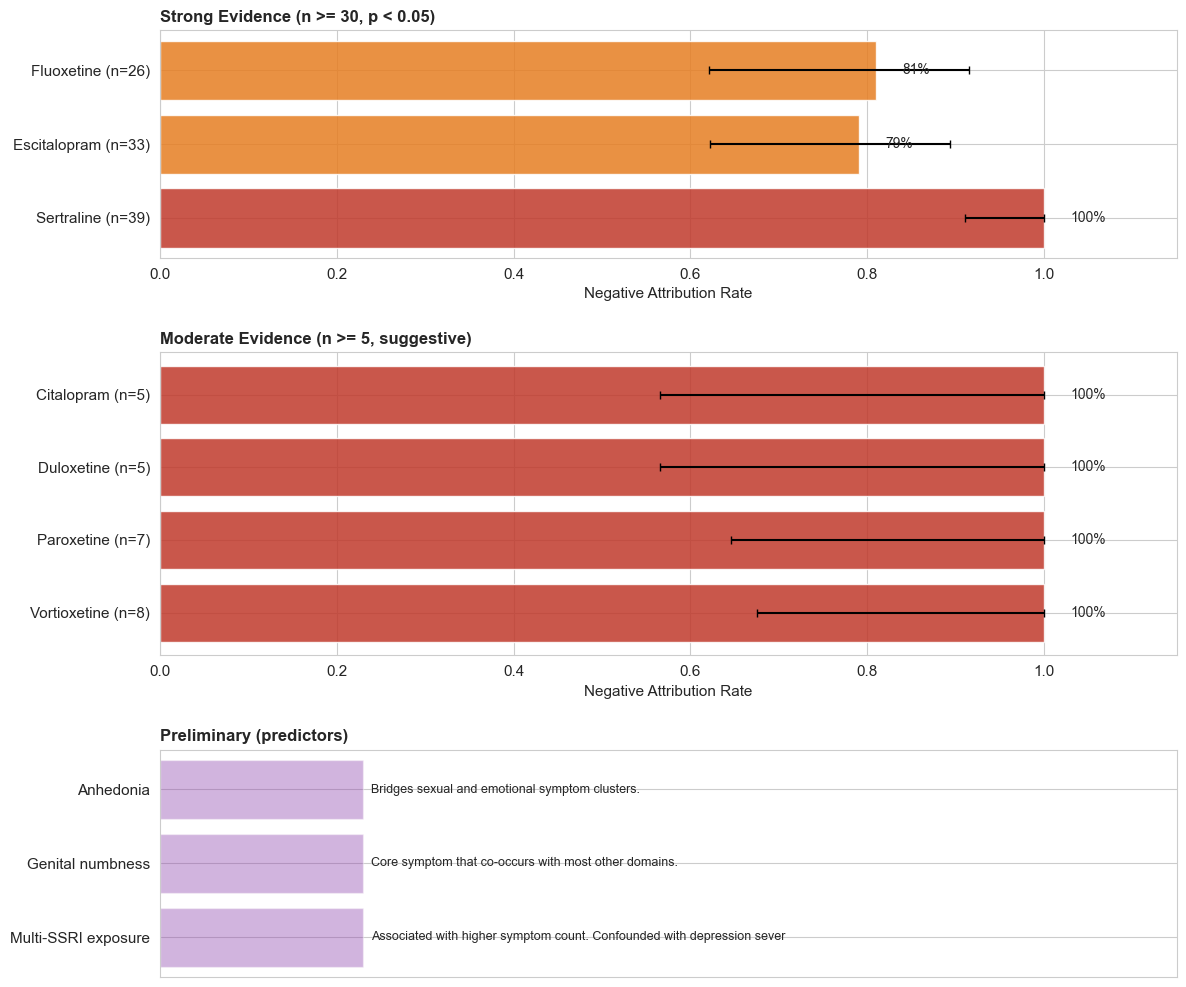

In [20]:

# ── Tiered findings ──
tiers = {
    'Strong Evidence (n >= 30, p < 0.05)': [
        ('Sertraline', 39, '100%', 'Highest negative consensus of any SSRI. Zero positive reports across 39 users.'),
        ('Escitalopram', 33, '79%', 'Second most-implicated. Some positive reports exist but are minority (12%).'),
        ('Fluoxetine', 26, '81%', 'Third most-implicated. Paradoxical positive reports in PSSD treatment context.'),
    ],
    'Moderate Evidence (n >= 5, suggestive)': [
        ('Vortioxetine', 8, '100%', 'Zero positive reports. Newer SSRI but equally implicated.'),
        ('Paroxetine', 7, '100%', 'Small sample but community descriptions emphasize severity and permanence.'),
        ('Duloxetine', 5, '100%', 'Highest symptom burden (5.0 domains average). SNRI, not SSRI.'),
        ('Citalopram', 5, '100%', 'High symptom burden (4.2 domains). Wide CIs due to small n.'),
    ],
    'Preliminary (predictors)': [
        ('Multi-SSRI exposure', None, None, 'Associated with higher symptom count. Confounded with depression severity.'),
        ('Genital numbness', None, None, 'Core symptom that co-occurs with most other domains.'),
        ('Anhedonia', None, None, 'Bridges sexual and emotional symptom clusters.'),
    ]
}

fig, axes = plt.subplots(3, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 4, 3]})

for idx, (tier_name, items) in enumerate(tiers.items()):
    ax = axes[idx]
    drug_items = [i for i in items if i[1] is not None]
    pred_items = [i for i in items if i[1] is None]

    if drug_items:
        names = [f"{name} (n={n})" for name, n, _, _ in drug_items]
        neg_rates_val = []
        for name, n, rate_str, _ in drug_items:
            rate_val = int(rate_str.strip('%')) / 100
            neg_rates_val.append(rate_val)

        y_pos_t = range(len(names))
        colors_t = ['#c0392b' if r >= 0.95 else '#e67e22' if r >= 0.75 else '#f1c40f' for r in neg_rates_val]
        bars_t = ax.barh(names, neg_rates_val, color=colors_t, alpha=0.85)

        # Add CIs where possible
        for i, (name, n, rate_str, _) in enumerate(drug_items):
            r = neg_rates_val[i]
            neg_count = int(round(r * n))
            ci_lo, ci_hi = wilson_ci(neg_count, n)
            ax.errorbar(r, i, xerr=[[r - ci_lo], [ci_hi - r]], fmt='none', ecolor='black', capsize=3, linewidth=1.5)
            ax.text(r + 0.03, i, f'{rate_str}', va='center', fontsize=10)

        ax.set_xlim(0, 1.15)
        ax.set_xlabel('Negative Attribution Rate')
    elif pred_items:
        names = [name for name, _, _, desc in pred_items]
        ax.barh(names, [0.5]*len(names), color='#8e44ad', alpha=0.4)
        for i, (_, _, _, desc) in enumerate(pred_items):
            ax.text(0.52, i, desc[:70], va='center', fontsize=9)
        ax.set_xlim(0, 2.5)
        ax.set_xlabel('')
        ax.set_xticks([])

    ax.set_title(tier_name, fontsize=12, fontweight='bold', loc='left')

plt.tight_layout(h_pad=2)
plt.show()


## 10. Conclusion

The r/PSSD community data paints a stark and consistent picture: every serotonergic antidepressant in this dataset carries overwhelming negative sentiment, and the community is remarkably unified in its harm attribution. But the data also reveals meaningful differences between drugs and informative patterns in who reports the worst outcomes.

Sertraline stands apart. With 39 users and a perfect 100% negative attribution rate, it is the most frequently and most unanimously blamed SSRI in this community. This is not just a function of prescribing prevalence -- the negative consensus is statistically tighter than for escitalopram (79% negative, n=33) or fluoxetine (81% negative, n=26), the second and third most commonly named drugs. Whether this reflects a genuine pharmacological difference (sertraline's dopamine reuptake inhibition, its higher serotonin transporter affinity) or a selection effect (sertraline is the most prescribed SSRI, so more PSSD cases arise from it, and only the most persistent cases remain active in the community) cannot be determined from observational community data.

On severity prediction, the most reliable signal is polypharmacy. Users exposed to multiple SSRIs report more symptom domains, though this is confounded with depression severity (patients who get switched between medications tend to have harder-to-treat conditions). Duloxetine and citalopram users report the highest per-person symptom burden, but with only 5 users each, these findings are preliminary. Among the larger groups, symptom counts are surprisingly similar -- suggesting that PSSD severity may depend more on individual susceptibility than on which specific SSRI caused it.

A patient or researcher should take away three things. First, sertraline is the drug this community most consistently associates with persistent harm, and that signal is strong enough to warrant clinical attention. Second, the character of PSSD varies -- some users experience isolated sexual dysfunction while others report a multi-system syndrome involving emotional blunting, cognitive changes, and anhedonia alongside genital symptoms. Third, the paradoxical finding that some users report benefit from the same drug class that caused their condition (microdosing, re-exposure) suggests the dose-response relationship in PSSD is not straightforward and deserves controlled investigation.

## 11. Research Limitations

**Selection bias.** r/PSSD is a self-selected community of people who believe they have PSSD. Members are not representative of all SSRI users, most of whom discontinue without persistent sexual side effects. The sample over-represents severe and persistent cases.

**Reporting bias.** Users who had worse experiences are more likely to post and post more frequently. The dominance of negative sentiment reflects who participates in this community, not the population-level rate of PSSD.

**Survivorship bias.** Users whose symptoms resolved may leave the community. The data disproportionately captures ongoing cases, inflating perceived severity and duration.

**Recall bias.** Users reporting on drug experiences months or years after exposure may misremember timing, severity, or which specific drug caused their symptoms. Attribution to a specific SSRI may be inaccurate when users tried multiple medications.

**Confounding.** Users who tried multiple SSRIs likely had more severe or treatment-resistant depression. Multi-SSRI exposure as a "predictor" of worse PSSD may actually reflect underlying vulnerability, not cumulative drug toxicity.

**No control group.** We have no data on SSRI users who did NOT develop PSSD. We cannot estimate risk ratios, prevalence, or absolute risk from this data.

**Sentiment vs. clinical severity.** Sentiment analysis captures how users talk about their experience, not the objective severity of their condition. A user who posts "this ruined my life" and a user who clinically documents moderate sexual dysfunction may receive different sentiment scores despite similar clinical profiles.

**Temporal snapshot.** One month of data (March-April 2026) from a single subreddit. Community norms, drug availability, and posting patterns change over time. Results may not generalize to other time periods or platforms.

In [21]:

display(HTML('<p style="font-size: 1.2em; font-weight: bold; font-style: italic;">These findings reflect reporting patterns in online communities, not population-level treatment effects. This is not medical advice.</p>'))
